In [1]:
!pip install torch

In [2]:
import torch
import torch.nn as nn

In [3]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net_G = nn.Sequential(
        nn.ConvTranspose2d(75,256,4,1,0),
        nn.ReLU(),
        nn.ConvTranspose2d(256,128,4,2,1),
        nn.ReLU(),
        nn.ConvTranspose2d(128,64,4,2,1),
        nn.ReLU(),
        nn.ConvTranspose2d(64,3,4,2,1),
        nn.Tanh())


    def forward (self,x):
        return self.net_G(x)

In [4]:
batch_size=64
z = torch.randn(batch_size,3072)
#as CNN accept (batch,channel,height,width)
z=z.view(batch_size,3,32,32)
#this are not image Channel , this are feature Channel

In [5]:
net_D=nn.Sequential(
    nn.Conv2d(3,64,4,2),
    nn.LeakyReLU(0.2),
    nn.Conv2d(64,128,4,2),
    nn.LeakyReLU(0.2),
    nn.Conv2d(128,256,4,2),
    nn.LeakyReLU(0.2),
    nn.Conv2d(256,512,2,2),
    nn.LeakyReLU(0.2),
    nn.Conv2d(512,1,1,2),
    nn.Sigmoid()
)


In [6]:
x=torch.randn(batch_size,3,64,64)


In [7]:
out=net_D(x)
print(out.shape)

torch.Size([64, 1, 2, 2])


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = net_D.to(device)

In [9]:
criterion = nn.BCELoss()

In [10]:
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [11]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

In [12]:
transform = transforms.Compose(
    [#transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])]
)

In [13]:
data=torchvision.datasets.CIFAR10(
    download=True,
    train=True,
    transform=transform,
    root="./data"
)

Files already downloaded and verified


In [14]:
loader=DataLoader(data,batch_size=64,shuffle=True)

In [15]:
real = next(iter(loader))[0].to(device)
batch_size=real.size(0)
print(real.shape)

torch.Size([64, 3, 32, 32])


In [16]:
real_labels=torch.ones(batch_size).to(device)
fake_labels=torch.zeros(batch_size).to(device)

In [17]:
net_G= Generator().to(device)
net_D = net_D.to(device)

In [18]:
z=torch.randn(batch_size,75,1,1).to(device)
fake=net_G(z)


In [19]:
z.shape

torch.Size([64, 75, 1, 1])

In [20]:
D_real=net_D(real).view(-1)
D_fake=net_D(fake).detach().view(-1)

In [21]:
print(fake.shape,real.shape)

torch.Size([64, 3, 32, 32]) torch.Size([64, 3, 32, 32])


In [22]:
print(real_labels)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')


In [23]:
loss_real=criterion(D_real,real_labels).to(device)
loss_fake=criterion(D_fake,fake_labels).to(device)

loss_D = loss_fake+loss_real

In [24]:
opt_D.zero_grad()
loss_D.backward()
opt_D.step()

In [25]:
D_fake = net_D(fake).view(-1)
loss_G = criterion(D_fake,real_labels)

In [26]:
opt_G.zero_grad()
loss_G.backward()
opt_G.step()

In [27]:
print("D loss:", loss_D.item())
print("G loss:", loss_G.item())

D loss: 1.3836669921875
G loss: 0.6564643979072571


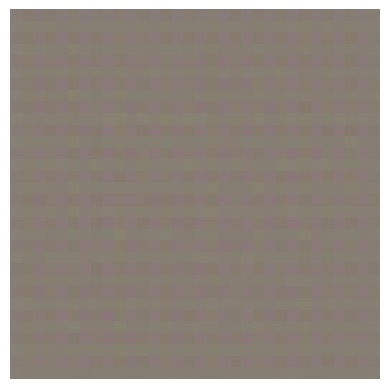

In [28]:
import matplotlib.pyplot as plt

img = fake[0].permute(2,1,0).detach().cpu().squeeze().numpy()
img = (img + 1) / 2

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [29]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


Epoch 0 | D Loss: 1.3668 | G Loss: 0.6498
Epoch 0 | D Loss: 1.3355 | G Loss: 0.6491
Epoch 0 | D Loss: 1.2774 | G Loss: 0.6480
Epoch 0 | D Loss: 1.1944 | G Loss: 0.6531
Epoch 0 | D Loss: 1.0718 | G Loss: 0.6737
Epoch 0 | D Loss: 0.9279 | G Loss: 0.7020
Epoch 0 | D Loss: 0.8266 | G Loss: 0.7313
Epoch 0 | D Loss: 0.7347 | G Loss: 0.7846
Epoch 0 | D Loss: 0.6662 | G Loss: 0.8635
Epoch 0 | D Loss: 0.6164 | G Loss: 0.9801
Epoch 0 | D Loss: 0.5400 | G Loss: 1.1720
Epoch 0 | D Loss: 0.4553 | G Loss: 1.4630
Epoch 0 | D Loss: 0.3510 | G Loss: 1.8859
Epoch 0 | D Loss: 0.2664 | G Loss: 2.3880
Epoch 0 | D Loss: 0.1696 | G Loss: 2.9874
Epoch 0 | D Loss: 0.1443 | G Loss: 3.3031
Epoch 0 | D Loss: 0.1031 | G Loss: 3.8788
Epoch 0 | D Loss: 0.1465 | G Loss: 3.5811
Epoch 0 | D Loss: 0.1994 | G Loss: 4.9811
Epoch 0 | D Loss: 0.5605 | G Loss: 2.3589
Epoch 0 | D Loss: 1.0782 | G Loss: 3.7197
Epoch 0 | D Loss: 0.2369 | G Loss: 4.2903
Epoch 0 | D Loss: 0.2821 | G Loss: 3.6452
Epoch 0 | D Loss: 0.2357 | G Loss:

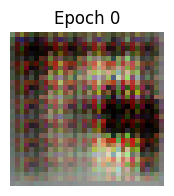

Epoch 1 | D Loss: 0.4012 | G Loss: 2.3664
Epoch 1 | D Loss: 0.4323 | G Loss: 2.2142
Epoch 1 | D Loss: 0.5093 | G Loss: 2.3794
Epoch 1 | D Loss: 0.5096 | G Loss: 2.4323
Epoch 1 | D Loss: 0.3235 | G Loss: 3.1177
Epoch 1 | D Loss: 0.2866 | G Loss: 3.0331
Epoch 1 | D Loss: 0.2953 | G Loss: 2.8159
Epoch 1 | D Loss: 0.3457 | G Loss: 3.1596
Epoch 1 | D Loss: 0.3005 | G Loss: 3.5529
Epoch 1 | D Loss: 0.3596 | G Loss: 2.8064
Epoch 1 | D Loss: 0.6187 | G Loss: 3.9238
Epoch 1 | D Loss: 0.4153 | G Loss: 4.0088
Epoch 1 | D Loss: 0.2305 | G Loss: 3.5361
Epoch 1 | D Loss: 0.5954 | G Loss: 5.0381
Epoch 1 | D Loss: 0.4883 | G Loss: 3.6357
Epoch 1 | D Loss: 0.3524 | G Loss: 3.0036
Epoch 1 | D Loss: 0.4476 | G Loss: 5.8852
Epoch 1 | D Loss: 0.5845 | G Loss: 5.0573
Epoch 1 | D Loss: 0.1900 | G Loss: 3.5359
Epoch 1 | D Loss: 0.2544 | G Loss: 3.2087
Epoch 1 | D Loss: 0.3223 | G Loss: 3.1976
Epoch 1 | D Loss: 0.1855 | G Loss: 3.4464
Epoch 1 | D Loss: 0.3382 | G Loss: 2.7606
Epoch 1 | D Loss: 0.2531 | G Loss:

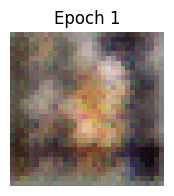

Epoch 2 | D Loss: 0.6285 | G Loss: 2.6813
Epoch 2 | D Loss: 1.1774 | G Loss: 3.0742
Epoch 2 | D Loss: 1.2008 | G Loss: 1.7584
Epoch 2 | D Loss: 1.2025 | G Loss: 2.9259
Epoch 2 | D Loss: 0.7216 | G Loss: 2.5774
Epoch 2 | D Loss: 0.6688 | G Loss: 2.0009
Epoch 2 | D Loss: 0.6802 | G Loss: 2.1059
Epoch 2 | D Loss: 0.5420 | G Loss: 3.0908
Epoch 2 | D Loss: 0.6719 | G Loss: 2.9091
Epoch 2 | D Loss: 0.5419 | G Loss: 2.4644
Epoch 2 | D Loss: 0.5410 | G Loss: 2.2712
Epoch 2 | D Loss: 0.5174 | G Loss: 2.9308
Epoch 2 | D Loss: 0.6144 | G Loss: 2.5411
Epoch 2 | D Loss: 0.5955 | G Loss: 2.5852
Epoch 2 | D Loss: 0.5540 | G Loss: 2.4344
Epoch 2 | D Loss: 0.7635 | G Loss: 2.3022
Epoch 2 | D Loss: 0.7380 | G Loss: 2.6114
Epoch 2 | D Loss: 0.6484 | G Loss: 2.0199
Epoch 2 | D Loss: 0.7970 | G Loss: 3.3434
Epoch 2 | D Loss: 0.7460 | G Loss: 2.5137
Epoch 2 | D Loss: 0.8383 | G Loss: 2.0959
Epoch 2 | D Loss: 0.8634 | G Loss: 2.7870
Epoch 2 | D Loss: 0.7814 | G Loss: 2.3868
Epoch 2 | D Loss: 0.7024 | G Loss:

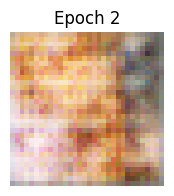

Epoch 3 | D Loss: 0.4627 | G Loss: 2.7392
Epoch 3 | D Loss: 0.4814 | G Loss: 2.6194
Epoch 3 | D Loss: 0.4245 | G Loss: 2.8933
Epoch 3 | D Loss: 0.4475 | G Loss: 2.8125
Epoch 3 | D Loss: 0.5583 | G Loss: 2.9227
Epoch 3 | D Loss: 0.4618 | G Loss: 2.7779
Epoch 3 | D Loss: 0.4583 | G Loss: 2.6437
Epoch 3 | D Loss: 0.4352 | G Loss: 3.3799
Epoch 3 | D Loss: 0.5745 | G Loss: 2.6128
Epoch 3 | D Loss: 0.5851 | G Loss: 2.6076
Epoch 3 | D Loss: 0.5650 | G Loss: 2.9661
Epoch 3 | D Loss: 0.6250 | G Loss: 2.7618
Epoch 3 | D Loss: 0.4927 | G Loss: 3.0243
Epoch 3 | D Loss: 0.6202 | G Loss: 2.6658
Epoch 3 | D Loss: 0.5955 | G Loss: 3.7563
Epoch 3 | D Loss: 0.8217 | G Loss: 2.7822
Epoch 3 | D Loss: 0.5874 | G Loss: 3.1485
Epoch 3 | D Loss: 0.6914 | G Loss: 3.5443
Epoch 3 | D Loss: 0.4808 | G Loss: 3.0674
Epoch 3 | D Loss: 0.5254 | G Loss: 3.1718
Epoch 3 | D Loss: 0.5720 | G Loss: 4.1953
Epoch 3 | D Loss: 0.4998 | G Loss: 3.6557
Epoch 3 | D Loss: 0.3885 | G Loss: 3.5402
Epoch 3 | D Loss: 0.4340 | G Loss:

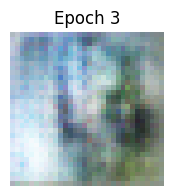

Epoch 4 | D Loss: 0.7666 | G Loss: 2.4519
Epoch 4 | D Loss: 0.7930 | G Loss: 2.1923
Epoch 4 | D Loss: 0.7409 | G Loss: 2.7305
Epoch 4 | D Loss: 0.7496 | G Loss: 2.2617
Epoch 4 | D Loss: 1.0422 | G Loss: 2.3383
Epoch 4 | D Loss: 0.9452 | G Loss: 1.6853
Epoch 4 | D Loss: 1.3046 | G Loss: 4.1039
Epoch 4 | D Loss: 1.3307 | G Loss: 2.8531
Epoch 4 | D Loss: 1.2121 | G Loss: 1.7430
Epoch 4 | D Loss: 1.1605 | G Loss: 2.9639
Epoch 4 | D Loss: 1.1392 | G Loss: 2.1187
Epoch 4 | D Loss: 0.8323 | G Loss: 2.1345
Epoch 4 | D Loss: 1.0081 | G Loss: 2.3083
Epoch 4 | D Loss: 0.5533 | G Loss: 2.2972
Epoch 4 | D Loss: 0.7060 | G Loss: 2.2343
Epoch 4 | D Loss: 0.6664 | G Loss: 2.0620
Epoch 4 | D Loss: 0.5589 | G Loss: 2.5994
Epoch 4 | D Loss: 0.6091 | G Loss: 2.5424
Epoch 4 | D Loss: 0.6413 | G Loss: 1.9347
Epoch 4 | D Loss: 0.8335 | G Loss: 2.8860
Epoch 4 | D Loss: 0.7951 | G Loss: 2.4097
Epoch 4 | D Loss: 0.8712 | G Loss: 1.9800
Epoch 4 | D Loss: 0.7774 | G Loss: 2.7698
Epoch 4 | D Loss: 0.8137 | G Loss:

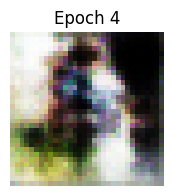

Epoch 5 | D Loss: 0.8130 | G Loss: 2.5785
Epoch 5 | D Loss: 0.8496 | G Loss: 2.7630
Epoch 5 | D Loss: 0.6401 | G Loss: 2.6309
Epoch 5 | D Loss: 1.3202 | G Loss: 2.6156
Epoch 5 | D Loss: 0.6145 | G Loss: 2.7786
Epoch 5 | D Loss: 0.7742 | G Loss: 2.0989
Epoch 5 | D Loss: 0.9122 | G Loss: 2.2078
Epoch 5 | D Loss: 1.1069 | G Loss: 2.3290
Epoch 5 | D Loss: 0.8922 | G Loss: 2.0935
Epoch 5 | D Loss: 0.8765 | G Loss: 1.8995
Epoch 5 | D Loss: 1.1256 | G Loss: 2.8364
Epoch 5 | D Loss: 1.0614 | G Loss: 2.1525
Epoch 5 | D Loss: 0.8767 | G Loss: 1.6381
Epoch 5 | D Loss: 1.1325 | G Loss: 2.6036
Epoch 5 | D Loss: 0.9794 | G Loss: 1.9975
Epoch 5 | D Loss: 0.9036 | G Loss: 1.8465
Epoch 5 | D Loss: 0.8598 | G Loss: 2.1128
Epoch 5 | D Loss: 0.8481 | G Loss: 2.0285
Epoch 5 | D Loss: 0.7676 | G Loss: 1.9658
Epoch 5 | D Loss: 0.8050 | G Loss: 2.2280
Epoch 5 | D Loss: 0.6361 | G Loss: 1.9665
Epoch 5 | D Loss: 0.7581 | G Loss: 2.1310
Epoch 5 | D Loss: 0.7943 | G Loss: 2.0822
Epoch 5 | D Loss: 0.7513 | G Loss:

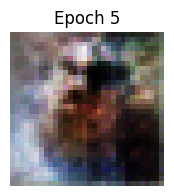

Epoch 6 | D Loss: 0.8844 | G Loss: 2.2521
Epoch 6 | D Loss: 0.8666 | G Loss: 1.9606
Epoch 6 | D Loss: 0.6078 | G Loss: 2.0748
Epoch 6 | D Loss: 0.6303 | G Loss: 2.0821
Epoch 6 | D Loss: 0.7721 | G Loss: 2.1126
Epoch 6 | D Loss: 0.9132 | G Loss: 1.8506
Epoch 6 | D Loss: 1.0157 | G Loss: 2.0852
Epoch 6 | D Loss: 0.9329 | G Loss: 1.9477
Epoch 6 | D Loss: 0.7742 | G Loss: 1.9924
Epoch 6 | D Loss: 0.8229 | G Loss: 2.1007
Epoch 6 | D Loss: 0.8342 | G Loss: 2.0199
Epoch 6 | D Loss: 0.7458 | G Loss: 2.2338
Epoch 6 | D Loss: 0.6595 | G Loss: 2.1801
Epoch 6 | D Loss: 0.5882 | G Loss: 2.2807
Epoch 6 | D Loss: 0.5067 | G Loss: 2.7434
Epoch 6 | D Loss: 0.6955 | G Loss: 2.3878
Epoch 6 | D Loss: 0.5547 | G Loss: 1.8945
Epoch 6 | D Loss: 0.7478 | G Loss: 3.2387
Epoch 6 | D Loss: 0.6611 | G Loss: 2.4774
Epoch 6 | D Loss: 0.5209 | G Loss: 2.5054
Epoch 6 | D Loss: 0.7693 | G Loss: 2.3261
Epoch 6 | D Loss: 0.6715 | G Loss: 2.5418
Epoch 6 | D Loss: 0.5311 | G Loss: 2.3274
Epoch 6 | D Loss: 0.6397 | G Loss:

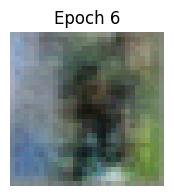

Epoch 7 | D Loss: 0.9758 | G Loss: 2.3405
Epoch 7 | D Loss: 0.6821 | G Loss: 2.0371
Epoch 7 | D Loss: 0.5402 | G Loss: 2.0348
Epoch 7 | D Loss: 0.5938 | G Loss: 2.0038
Epoch 7 | D Loss: 0.6250 | G Loss: 2.4230
Epoch 7 | D Loss: 0.7299 | G Loss: 2.1067
Epoch 7 | D Loss: 0.6932 | G Loss: 2.0280
Epoch 7 | D Loss: 0.8893 | G Loss: 2.3496
Epoch 7 | D Loss: 0.7888 | G Loss: 2.3867
Epoch 7 | D Loss: 0.8458 | G Loss: 1.7941
Epoch 7 | D Loss: 1.4629 | G Loss: 3.3803
Epoch 7 | D Loss: 1.2723 | G Loss: 2.3112
Epoch 7 | D Loss: 0.8700 | G Loss: 1.3697
Epoch 7 | D Loss: 1.0234 | G Loss: 2.7657
Epoch 7 | D Loss: 1.0247 | G Loss: 2.5440
Epoch 7 | D Loss: 0.7908 | G Loss: 1.8764
Epoch 7 | D Loss: 0.6719 | G Loss: 1.8389
Epoch 7 | D Loss: 0.6499 | G Loss: 2.0970
Epoch 7 | D Loss: 0.6532 | G Loss: 2.4549
Epoch 7 | D Loss: 0.8371 | G Loss: 1.7731
Epoch 7 | D Loss: 0.8324 | G Loss: 1.6502
Epoch 7 | D Loss: 0.7524 | G Loss: 1.9643
Epoch 7 | D Loss: 0.5776 | G Loss: 2.1276
Epoch 7 | D Loss: 0.6528 | G Loss:

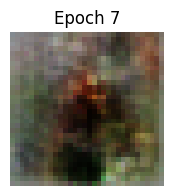

Epoch 8 | D Loss: 0.8898 | G Loss: 1.6891
Epoch 8 | D Loss: 1.0550 | G Loss: 2.2835
Epoch 8 | D Loss: 0.7749 | G Loss: 1.9101
Epoch 8 | D Loss: 0.6253 | G Loss: 2.0091
Epoch 8 | D Loss: 0.6679 | G Loss: 2.2634
Epoch 8 | D Loss: 0.8635 | G Loss: 1.8782
Epoch 8 | D Loss: 0.7858 | G Loss: 1.9026
Epoch 8 | D Loss: 0.6463 | G Loss: 2.5475
Epoch 8 | D Loss: 0.7008 | G Loss: 2.0642
Epoch 8 | D Loss: 0.8389 | G Loss: 2.2440
Epoch 8 | D Loss: 0.6472 | G Loss: 2.4142
Epoch 8 | D Loss: 0.7420 | G Loss: 2.3669
Epoch 8 | D Loss: 0.5822 | G Loss: 2.1006
Epoch 8 | D Loss: 0.4997 | G Loss: 2.3492
Epoch 8 | D Loss: 0.7201 | G Loss: 2.0027
Epoch 8 | D Loss: 0.5172 | G Loss: 2.4745
Epoch 8 | D Loss: 0.7359 | G Loss: 1.9939
Epoch 8 | D Loss: 0.6968 | G Loss: 2.2127
Epoch 8 | D Loss: 0.7659 | G Loss: 2.1424
Epoch 8 | D Loss: 0.7717 | G Loss: 2.0626
Epoch 8 | D Loss: 0.8731 | G Loss: 2.1710
Epoch 8 | D Loss: 1.0592 | G Loss: 2.5427
Epoch 8 | D Loss: 1.3493 | G Loss: 1.4777
Epoch 8 | D Loss: 1.1308 | G Loss:

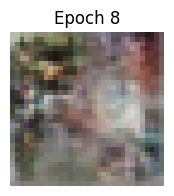

Epoch 9 | D Loss: 1.0433 | G Loss: 2.5910
Epoch 9 | D Loss: 0.7420 | G Loss: 2.1733
Epoch 9 | D Loss: 0.7989 | G Loss: 2.4262
Epoch 9 | D Loss: 0.6761 | G Loss: 1.9644
Epoch 9 | D Loss: 0.8894 | G Loss: 3.0577
Epoch 9 | D Loss: 1.0877 | G Loss: 2.2543
Epoch 9 | D Loss: 1.0337 | G Loss: 2.0138
Epoch 9 | D Loss: 0.8185 | G Loss: 2.0313
Epoch 9 | D Loss: 0.7606 | G Loss: 2.1503
Epoch 9 | D Loss: 0.8064 | G Loss: 2.2073
Epoch 9 | D Loss: 0.8846 | G Loss: 1.9561
Epoch 9 | D Loss: 1.0084 | G Loss: 2.1927
Epoch 9 | D Loss: 1.1972 | G Loss: 1.5618
Epoch 9 | D Loss: 1.0082 | G Loss: 1.7861
Epoch 9 | D Loss: 1.2135 | G Loss: 2.0542
Epoch 9 | D Loss: 1.2130 | G Loss: 1.6670
Epoch 9 | D Loss: 1.2044 | G Loss: 1.4577
Epoch 9 | D Loss: 0.6796 | G Loss: 1.8370
Epoch 9 | D Loss: 0.5352 | G Loss: 1.9109
Epoch 9 | D Loss: 0.5201 | G Loss: 1.9413
Epoch 9 | D Loss: 0.5185 | G Loss: 2.4577
Epoch 9 | D Loss: 0.5061 | G Loss: 2.0132
Epoch 9 | D Loss: 0.5225 | G Loss: 2.0290
Epoch 9 | D Loss: 0.6333 | G Loss:

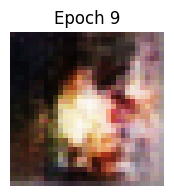

Epoch 10 | D Loss: 0.9626 | G Loss: 1.7087
Epoch 10 | D Loss: 0.6368 | G Loss: 1.9733
Epoch 10 | D Loss: 0.7371 | G Loss: 1.9289
Epoch 10 | D Loss: 0.8123 | G Loss: 1.7271
Epoch 10 | D Loss: 1.1799 | G Loss: 1.9531
Epoch 10 | D Loss: 0.9316 | G Loss: 2.0376
Epoch 10 | D Loss: 0.9694 | G Loss: 1.4913
Epoch 10 | D Loss: 0.9388 | G Loss: 1.7288
Epoch 10 | D Loss: 1.1106 | G Loss: 1.8637
Epoch 10 | D Loss: 1.0418 | G Loss: 1.6481
Epoch 10 | D Loss: 1.0199 | G Loss: 1.6632
Epoch 10 | D Loss: 1.0235 | G Loss: 1.8236
Epoch 10 | D Loss: 0.9845 | G Loss: 1.6631
Epoch 10 | D Loss: 1.0820 | G Loss: 1.4369
Epoch 10 | D Loss: 1.3109 | G Loss: 1.8974
Epoch 10 | D Loss: 0.9376 | G Loss: 1.8932
Epoch 10 | D Loss: 0.9722 | G Loss: 1.8487
Epoch 10 | D Loss: 0.7968 | G Loss: 1.6856
Epoch 10 | D Loss: 0.8410 | G Loss: 2.0238
Epoch 10 | D Loss: 0.6834 | G Loss: 1.9760
Epoch 10 | D Loss: 0.7628 | G Loss: 1.5666
Epoch 10 | D Loss: 0.8995 | G Loss: 1.9515
Epoch 10 | D Loss: 0.9839 | G Loss: 1.8661
Epoch 10 | 

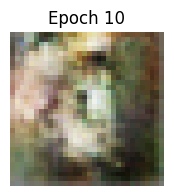

Epoch 11 | D Loss: 1.3387 | G Loss: 2.1551
Epoch 11 | D Loss: 1.0226 | G Loss: 1.8837
Epoch 11 | D Loss: 1.3559 | G Loss: 2.6266
Epoch 11 | D Loss: 0.9417 | G Loss: 2.0335
Epoch 11 | D Loss: 1.1531 | G Loss: 1.8157
Epoch 11 | D Loss: 0.9620 | G Loss: 1.6677
Epoch 11 | D Loss: 0.7551 | G Loss: 1.8591
Epoch 11 | D Loss: 0.7246 | G Loss: 1.8258
Epoch 11 | D Loss: 0.6339 | G Loss: 1.6100
Epoch 11 | D Loss: 0.8747 | G Loss: 2.0412
Epoch 11 | D Loss: 0.9264 | G Loss: 1.7448
Epoch 11 | D Loss: 0.9231 | G Loss: 1.4092
Epoch 11 | D Loss: 1.0754 | G Loss: 1.6667
Epoch 11 | D Loss: 1.0487 | G Loss: 1.8045
Epoch 11 | D Loss: 0.9506 | G Loss: 1.5993
Epoch 11 | D Loss: 1.1174 | G Loss: 1.6467
Epoch 11 | D Loss: 1.0821 | G Loss: 1.5869
Epoch 11 | D Loss: 0.9017 | G Loss: 1.7558
Epoch 11 | D Loss: 0.8445 | G Loss: 1.8850
Epoch 11 | D Loss: 0.7232 | G Loss: 1.9619
Epoch 11 | D Loss: 0.8215 | G Loss: 1.9466
Epoch 11 | D Loss: 0.8196 | G Loss: 1.8476
Epoch 11 | D Loss: 0.9728 | G Loss: 2.0626
Epoch 11 | 

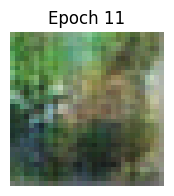

Epoch 12 | D Loss: 0.9113 | G Loss: 2.0127
Epoch 12 | D Loss: 0.9384 | G Loss: 1.9441
Epoch 12 | D Loss: 0.9569 | G Loss: 1.6960
Epoch 12 | D Loss: 0.8636 | G Loss: 1.6276
Epoch 12 | D Loss: 0.9282 | G Loss: 1.6358
Epoch 12 | D Loss: 0.9336 | G Loss: 1.9337
Epoch 12 | D Loss: 0.7377 | G Loss: 1.9051
Epoch 12 | D Loss: 0.7479 | G Loss: 1.6424
Epoch 12 | D Loss: 0.6971 | G Loss: 1.5912
Epoch 12 | D Loss: 0.8383 | G Loss: 1.7738
Epoch 12 | D Loss: 0.7521 | G Loss: 1.9613
Epoch 12 | D Loss: 0.8500 | G Loss: 1.6270
Epoch 12 | D Loss: 1.1271 | G Loss: 1.5552
Epoch 12 | D Loss: 1.0065 | G Loss: 1.5010
Epoch 12 | D Loss: 1.0539 | G Loss: 1.7760
Epoch 12 | D Loss: 0.8204 | G Loss: 1.6598
Epoch 12 | D Loss: 0.8642 | G Loss: 1.3536
Epoch 12 | D Loss: 0.8928 | G Loss: 1.5605
Epoch 12 | D Loss: 0.9233 | G Loss: 1.8267
Epoch 12 | D Loss: 1.1595 | G Loss: 1.4568
Epoch 12 | D Loss: 1.0697 | G Loss: 1.6619
Epoch 12 | D Loss: 0.8996 | G Loss: 1.5859
Epoch 12 | D Loss: 1.0225 | G Loss: 1.5193
Epoch 12 | 

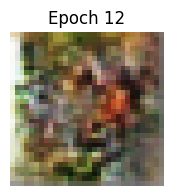

Epoch 13 | D Loss: 0.9102 | G Loss: 1.7920
Epoch 13 | D Loss: 0.8751 | G Loss: 1.6224
Epoch 13 | D Loss: 0.9572 | G Loss: 1.9031
Epoch 13 | D Loss: 0.8557 | G Loss: 1.8605
Epoch 13 | D Loss: 0.8191 | G Loss: 1.8180
Epoch 13 | D Loss: 0.8922 | G Loss: 1.6458
Epoch 13 | D Loss: 0.9363 | G Loss: 1.7062
Epoch 13 | D Loss: 0.8979 | G Loss: 1.8314
Epoch 13 | D Loss: 0.9932 | G Loss: 1.6441
Epoch 13 | D Loss: 1.0913 | G Loss: 1.2686
Epoch 13 | D Loss: 0.9756 | G Loss: 1.5984
Epoch 13 | D Loss: 0.9549 | G Loss: 1.6672
Epoch 13 | D Loss: 0.7972 | G Loss: 1.5186
Epoch 13 | D Loss: 0.9422 | G Loss: 1.7997
Epoch 13 | D Loss: 0.9337 | G Loss: 1.5427
Epoch 13 | D Loss: 0.8675 | G Loss: 1.4191
Epoch 13 | D Loss: 1.0041 | G Loss: 1.7376
Epoch 13 | D Loss: 0.8301 | G Loss: 1.6314
Epoch 13 | D Loss: 1.0013 | G Loss: 1.3244
Epoch 13 | D Loss: 0.9484 | G Loss: 1.9517
Epoch 13 | D Loss: 0.8744 | G Loss: 1.7036
Epoch 13 | D Loss: 0.8273 | G Loss: 1.7110
Epoch 13 | D Loss: 0.8388 | G Loss: 1.6529
Epoch 13 | 

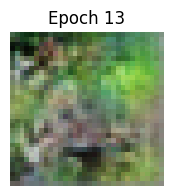

Epoch 14 | D Loss: 0.7580 | G Loss: 1.6737
Epoch 14 | D Loss: 0.8297 | G Loss: 1.5818
Epoch 14 | D Loss: 1.0548 | G Loss: 1.9630
Epoch 14 | D Loss: 0.9388 | G Loss: 1.8476
Epoch 14 | D Loss: 0.9915 | G Loss: 1.8073
Epoch 14 | D Loss: 1.0304 | G Loss: 1.6676
Epoch 14 | D Loss: 0.9850 | G Loss: 1.4222
Epoch 14 | D Loss: 1.2272 | G Loss: 2.0775
Epoch 14 | D Loss: 1.0457 | G Loss: 2.0159
Epoch 14 | D Loss: 0.7747 | G Loss: 1.7286
Epoch 14 | D Loss: 0.8910 | G Loss: 2.1568
Epoch 14 | D Loss: 0.7929 | G Loss: 1.9472
Epoch 14 | D Loss: 0.6779 | G Loss: 1.8109
Epoch 14 | D Loss: 0.8221 | G Loss: 2.2549
Epoch 14 | D Loss: 0.8007 | G Loss: 2.0921
Epoch 14 | D Loss: 0.7640 | G Loss: 1.8163
Epoch 14 | D Loss: 0.8718 | G Loss: 1.9828
Epoch 14 | D Loss: 0.7342 | G Loss: 1.7291
Epoch 14 | D Loss: 0.9151 | G Loss: 1.6424
Epoch 14 | D Loss: 1.0648 | G Loss: 1.6518
Epoch 14 | D Loss: 0.9985 | G Loss: 1.4677
Epoch 14 | D Loss: 0.9905 | G Loss: 1.5798
Epoch 14 | D Loss: 1.1253 | G Loss: 1.9716
Epoch 14 | 

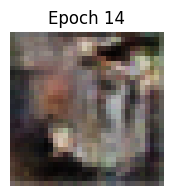

Epoch 15 | D Loss: 0.9576 | G Loss: 1.8712
Epoch 15 | D Loss: 1.1314 | G Loss: 1.7712
Epoch 15 | D Loss: 0.9997 | G Loss: 1.5113
Epoch 15 | D Loss: 0.8950 | G Loss: 1.5757
Epoch 15 | D Loss: 0.8806 | G Loss: 1.7027
Epoch 15 | D Loss: 0.8789 | G Loss: 1.8349
Epoch 15 | D Loss: 0.7343 | G Loss: 1.7747
Epoch 15 | D Loss: 0.6997 | G Loss: 1.9062
Epoch 15 | D Loss: 0.7555 | G Loss: 1.8048
Epoch 15 | D Loss: 0.8804 | G Loss: 1.8993
Epoch 15 | D Loss: 0.7515 | G Loss: 1.9760
Epoch 15 | D Loss: 0.7606 | G Loss: 1.8568
Epoch 15 | D Loss: 0.5724 | G Loss: 1.8034
Epoch 15 | D Loss: 0.7082 | G Loss: 1.7790
Epoch 15 | D Loss: 0.8024 | G Loss: 1.5622
Epoch 15 | D Loss: 1.0365 | G Loss: 1.5542
Epoch 15 | D Loss: 0.9432 | G Loss: 1.5883
Epoch 15 | D Loss: 0.9834 | G Loss: 1.4724
Epoch 15 | D Loss: 0.8051 | G Loss: 1.4404
Epoch 15 | D Loss: 1.1428 | G Loss: 1.8003
Epoch 15 | D Loss: 1.0870 | G Loss: 1.9837
Epoch 15 | D Loss: 1.0118 | G Loss: 1.5489
Epoch 15 | D Loss: 0.9532 | G Loss: 1.4359
Epoch 15 | 

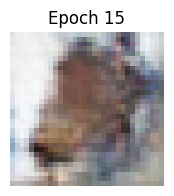

Epoch 16 | D Loss: 0.9547 | G Loss: 1.8207
Epoch 16 | D Loss: 0.8458 | G Loss: 1.6228
Epoch 16 | D Loss: 0.8349 | G Loss: 1.5605
Epoch 16 | D Loss: 0.8345 | G Loss: 1.6468
Epoch 16 | D Loss: 0.8596 | G Loss: 1.9063
Epoch 16 | D Loss: 0.9194 | G Loss: 2.2155
Epoch 16 | D Loss: 1.1253 | G Loss: 1.7504
Epoch 16 | D Loss: 1.1878 | G Loss: 1.7104
Epoch 16 | D Loss: 1.0798 | G Loss: 1.6985
Epoch 16 | D Loss: 0.9082 | G Loss: 1.7441
Epoch 16 | D Loss: 1.0369 | G Loss: 1.6897
Epoch 16 | D Loss: 0.8438 | G Loss: 1.6902
Epoch 16 | D Loss: 0.9469 | G Loss: 1.7475
Epoch 16 | D Loss: 0.8439 | G Loss: 1.7604
Epoch 16 | D Loss: 0.9532 | G Loss: 2.2869
Epoch 16 | D Loss: 0.9286 | G Loss: 1.7725
Epoch 16 | D Loss: 0.8932 | G Loss: 1.5635
Epoch 16 | D Loss: 0.8793 | G Loss: 1.6015
Epoch 16 | D Loss: 1.0676 | G Loss: 1.8056
Epoch 16 | D Loss: 0.9700 | G Loss: 1.7267
Epoch 16 | D Loss: 1.0413 | G Loss: 1.5830
Epoch 16 | D Loss: 0.7463 | G Loss: 1.9345
Epoch 16 | D Loss: 0.8557 | G Loss: 1.8774
Epoch 16 | 

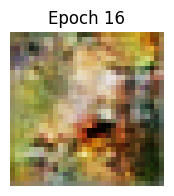

Epoch 17 | D Loss: 0.8629 | G Loss: 2.0505
Epoch 17 | D Loss: 0.8231 | G Loss: 1.8010
Epoch 17 | D Loss: 1.0957 | G Loss: 1.6997
Epoch 17 | D Loss: 0.9152 | G Loss: 2.1151
Epoch 17 | D Loss: 0.8766 | G Loss: 1.9626
Epoch 17 | D Loss: 0.9318 | G Loss: 1.6979
Epoch 17 | D Loss: 0.9433 | G Loss: 1.8790
Epoch 17 | D Loss: 1.0194 | G Loss: 1.8622
Epoch 17 | D Loss: 1.3081 | G Loss: 1.5303
Epoch 17 | D Loss: 0.9607 | G Loss: 1.9320
Epoch 17 | D Loss: 1.0943 | G Loss: 1.5730
Epoch 17 | D Loss: 1.0274 | G Loss: 1.5551
Epoch 17 | D Loss: 0.9835 | G Loss: 1.8428
Epoch 17 | D Loss: 0.8879 | G Loss: 1.6320
Epoch 17 | D Loss: 0.9117 | G Loss: 1.9234
Epoch 17 | D Loss: 0.6885 | G Loss: 1.8698
Epoch 17 | D Loss: 0.7303 | G Loss: 1.6943
Epoch 17 | D Loss: 0.7169 | G Loss: 1.8463
Epoch 17 | D Loss: 0.6325 | G Loss: 1.9126
Epoch 17 | D Loss: 0.6642 | G Loss: 1.8141
Epoch 17 | D Loss: 0.7528 | G Loss: 1.6851
Epoch 17 | D Loss: 1.0280 | G Loss: 1.6004
Epoch 17 | D Loss: 0.9185 | G Loss: 1.5604
Epoch 17 | 

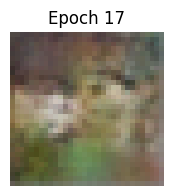

Epoch 18 | D Loss: 0.9417 | G Loss: 1.5114
Epoch 18 | D Loss: 1.1778 | G Loss: 1.5412
Epoch 18 | D Loss: 1.1089 | G Loss: 1.8842
Epoch 18 | D Loss: 1.0520 | G Loss: 1.6340
Epoch 18 | D Loss: 1.0975 | G Loss: 1.5279
Epoch 18 | D Loss: 1.0536 | G Loss: 1.5918
Epoch 18 | D Loss: 0.8462 | G Loss: 1.5449
Epoch 18 | D Loss: 1.0144 | G Loss: 1.6469
Epoch 18 | D Loss: 0.9715 | G Loss: 1.8795
Epoch 18 | D Loss: 0.9511 | G Loss: 1.8935
Epoch 18 | D Loss: 0.8201 | G Loss: 1.5547
Epoch 18 | D Loss: 0.9393 | G Loss: 1.8303
Epoch 18 | D Loss: 0.9464 | G Loss: 1.7806
Epoch 18 | D Loss: 0.8422 | G Loss: 1.8808
Epoch 18 | D Loss: 1.0482 | G Loss: 1.5585
Epoch 18 | D Loss: 0.8798 | G Loss: 1.5189
Epoch 18 | D Loss: 0.8754 | G Loss: 1.7045
Epoch 18 | D Loss: 0.8189 | G Loss: 1.7547
Epoch 18 | D Loss: 0.8983 | G Loss: 1.5180
Epoch 18 | D Loss: 1.0519 | G Loss: 2.0308
Epoch 18 | D Loss: 0.8294 | G Loss: 1.7698
Epoch 18 | D Loss: 1.0546 | G Loss: 1.8325
Epoch 18 | D Loss: 0.9365 | G Loss: 1.5380
Epoch 18 | 

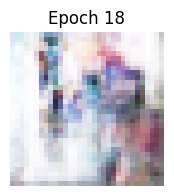

Epoch 19 | D Loss: 0.8317 | G Loss: 2.0806
Epoch 19 | D Loss: 0.8553 | G Loss: 1.8810
Epoch 19 | D Loss: 0.9677 | G Loss: 1.7042
Epoch 19 | D Loss: 0.9445 | G Loss: 1.7442
Epoch 19 | D Loss: 1.1377 | G Loss: 1.8669
Epoch 19 | D Loss: 0.9758 | G Loss: 1.9725
Epoch 19 | D Loss: 0.8489 | G Loss: 1.7032
Epoch 19 | D Loss: 0.8753 | G Loss: 1.6722
Epoch 19 | D Loss: 0.9320 | G Loss: 1.8759
Epoch 19 | D Loss: 0.9038 | G Loss: 1.7799
Epoch 19 | D Loss: 0.8813 | G Loss: 1.9283
Epoch 19 | D Loss: 0.7890 | G Loss: 1.9719
Epoch 19 | D Loss: 0.6826 | G Loss: 1.9608
Epoch 19 | D Loss: 0.7484 | G Loss: 1.9330
Epoch 19 | D Loss: 0.8812 | G Loss: 1.7668
Epoch 19 | D Loss: 0.8364 | G Loss: 2.1191
Epoch 19 | D Loss: 0.6628 | G Loss: 2.0909
Epoch 19 | D Loss: 0.8736 | G Loss: 1.7515
Epoch 19 | D Loss: 0.8070 | G Loss: 2.2232
Epoch 19 | D Loss: 0.9094 | G Loss: 2.1221
Epoch 19 | D Loss: 1.0077 | G Loss: 1.7907
Epoch 19 | D Loss: 1.1095 | G Loss: 1.4132
Epoch 19 | D Loss: 0.9319 | G Loss: 1.7715
Epoch 19 | 

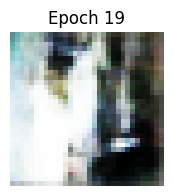

In [30]:
epochs = 20

for epoch in range(epochs):
    for real, _ in loader:

        real = real.to(device)
        batch_size = real.size(0)
        z=torch.randn(batch_size,75,1,1).to(device)
        fake = G(z)
        D_real = D(real).view(-1)
        D_fake = D(fake.detach()).view(-1)

        real_labels = torch.ones(batch_size).to(device)
        fake_labels = torch.zeros(batch_size).to(device)

        loss_real = criterion(D_real, real_labels)
        loss_fake = criterion(D_fake, fake_labels)

        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()
        D_fake = D(fake).view(-1)

        loss_G = criterion(D_fake, real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
        print(f"Epoch {epoch} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    if epoch % 1 == 0:
        import matplotlib.pyplot as plt

        img = fake[0].permute(2,1,0).detach().cpu().squeeze().numpy()
        img = (img + 1) / 2

        plt.figure(figsize=(2,2))
        plt.imshow(img, cmap='gray')
        plt.title(f"Epoch {epoch}")
        plt.axis('off')
        plt.show()